Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 86s 265ms/step - accuracy: 0.7904 - loss: 0.4383 - val_accuracy: 0.8586 - val_loss: 0.3521
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 269ms/step - accuracy: 0.9005 - loss: 0.2517 - val_accuracy: 0.8786 - val_loss: 0.3037
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 268ms/step - accuracy: 0.9351 - loss: 0.1704 - val_accuracy: 0.8662 - val_loss: 0.3344
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 263ms/step - accuracy: 0.9516 - loss: 0.1324 - val_accuracy: 0.8372 - val_loss: 0.3871
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 265ms/step - accuracy: 0.9656 - loss: 0.0971 - val_accuracy: 0.8488 - val_loss: 0.4354
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.8503 - loss: 0.4518
Test Accuracy: 0.8502799868583679


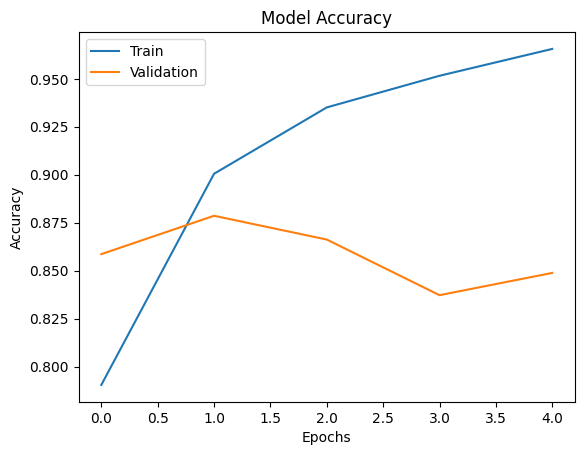

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Load Dataset
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

# 2. Preprocess (Padding)
max_len = 200
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

# 3. Build Model
model = Sequential()
model.add(Embedding(vocab_size, 128, input_length=max_len))
model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))

# 4. Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Train
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# 6. Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

# 7. Plot Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()